# 实验三：回归

## 实验目标

1. 使用 `scikit-learn` 加载并探索 **加州房价（California Housing）** 表格数据集。
2. 理解**回归任务**与分类任务的区别，掌握**特征标准化**及其防数据泄漏的正确做法。
3. 搭建**多层感知机（MLP）**，输出层为**单个连续值**。
4. 用 **MSE 损失**训练，并用 **RMSE / MAE / R²** 和**预测散点图**评估回归效果。



## 0. 环境准备

沿用前面实验的 conda 环境即可（需 `torch`、`scikit-learn`、`matplotlib`）：

```bash
conda activate rl-course
# 如缺少依赖：
# %pip install torch scikit-learn matplotlib
```


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch 版本:", torch.__version__)
print("使用设备:", device)

torch 版本: 2.13.0+cpu
使用设备: cpu


## 1. 加载与探索加州房价数据集

**加州房价数据集**来自 1990 年美国人口普查，共 **20640 个街区**，每个街区用 **8 个特征**描述，预测街区房价（单位：**10 万美元**）。

| 特征 | 含义 |
|---|---|
| MedInc | 街区收入中位数 |
| HouseAge | 房屋年龄中位数 |
| AveRooms | 平均房间数 |
| AveBedrms | 平均卧室数 |
| Population | 街区人口 |
| AveOccup | 平均入住率 |
| Latitude | 纬度 |
| Longitude | 经度 |


In [3]:
data = fetch_california_housing()
X, y = data.data, data.target            # X: (20640, 8), y: (20640,)
feature_names = data.feature_names

# ---- 剔除房价被截断在上限 5.0 的街区 ----
# 该数据集把所有真实房价 >=50万美元的街区都统一记成 5.00001
# 让模型在高价区系统性低估。这里直接去掉它们。
mask = y < 5.0
n_removed = int((~mask).sum())
X, y = X[mask], y[mask]
print(f"已剔除房价=5.0的街区 {n_removed} 个")

print("样本数:", X.shape[0], " 特征数:", X.shape[1])
print("特征名:", feature_names)
print("房价(目标)范围: {:.2f} ~ {:.2f} (单位:10万美元)".format(y.min(), y.max()))
print("房价均值: {:.2f}  中位数: {:.2f}".format(y.mean(), np.median(y)))

已剔除房价=5.0的街区 992 个
样本数: 19648  特征数: 8
特征名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
房价(目标)范围: 0.15 ~ 4.99 (单位:10万美元)
房价均值: 1.92  中位数: 1.74


先看看房价的分布，以及哪些特征和房价最相关：

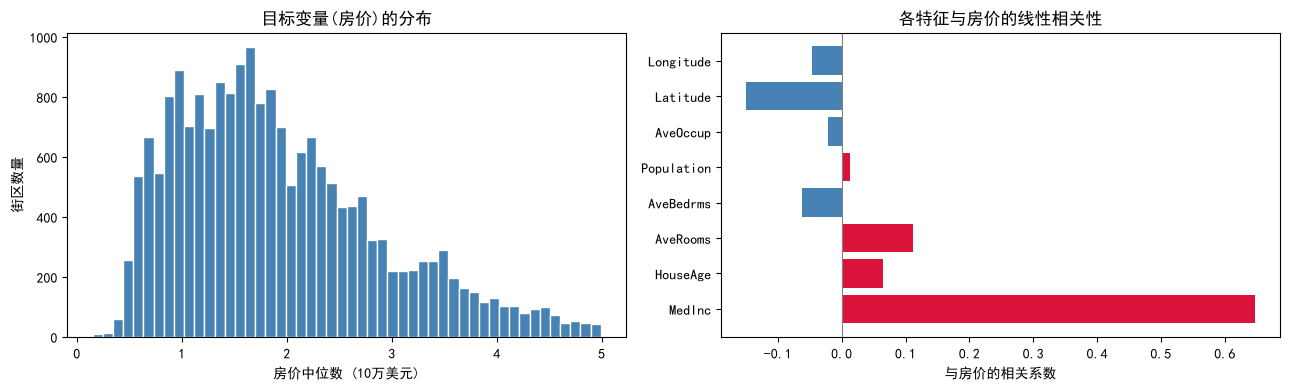

与房价最正相关的特征: MedInc (0.647)


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# 房价分布直方图
ax1.hist(y, bins=50, color="steelblue", edgecolor="white")
ax1.set_xlabel("房价中位数 (10万美元)"); ax1.set_ylabel("街区数量")
ax1.set_title("目标变量(房价)的分布")

# 各特征与房价的相关系数
corr = np.array([np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])])
colors = ["crimson" if c > 0 else "steelblue" for c in corr]
ax2.barh(feature_names, corr, color=colors)
ax2.set_xlabel("与房价的相关系数"); ax2.set_title("各特征与房价的线性相关性")
ax2.axvline(0, color="gray", lw=0.8)

plt.tight_layout()
plt.show()

print("与房价最正相关的特征:", feature_names[int(corr.argmax())], f"({corr.max():.3f})")

## 2. 划分数据集与特征标准化

### 2.1 训练 / 测试划分

先把数据按 **8:2** 分成训练集和测试集。测试集全程只在最后评估时使用。

### 2.2 标准化

看上面的特征：`Population` 动辄上千，`AveBedrms` 却只有 1 左右——**量纲差异巨大**。若不处理，`数值大的特征会主导梯度`。

**标准化**把每个特征变成"零均值、单位方差"：

$$
x' = \frac{x - \mu}{\sigma}
$$

> 防数据泄漏：均值 $\mu$ 和标准差 $\sigma$ **只能用训练集**统计，再用同一组 $\mu,\sigma$ 去变换测试集。


In [5]:
# 8:2 划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print("训练集:", X_train.shape[0], " 测试集:", X_test.shape[0])

#  标准化
mu    = X_train.mean(axis=0)               # 每个特征的均值
sigma = X_train.std(axis=0)                # 每个特征的标准差

X_train = (X_train - mu) / sigma           # 用训练集的 mu/sigma 变换训练集
X_test  = (X_test  - mu) / sigma           # 用同一组 mu/sigma 变换测试集

print("标准化后训练集各特征均值(应≈0):", np.round(X_train.mean(axis=0), 3))
print("标准化后训练集各特征标准差(应≈1):", np.round(X_train.std(axis=0), 3))

训练集: 15718  测试集: 3930
标准化后训练集各特征均值(应≈0): [-0.  0.  0. -0.  0. -0. -0. -0.]
标准化后训练集各特征标准差(应≈1): [1. 1. 1. 1. 1. 1. 1. 1.]


### 2.3 转成张量与 DataLoader

把 NumPy 数组转成 PyTorch 张量。注意目标 `y` 要 reshape 成 **`(N, 1)`** 的列向量，以便和网络输出 `(N, 1)` 对齐。

In [6]:
# 转成 float32 张量；y 变成列向量 (N, 1)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("一个batch：","feature:", xb.shape, " target:", yb.shape)

一个batch： feature: torch.Size([64, 8])  target: torch.Size([64, 1])


## 3. 搭建多层感知机（MLP）

### 回归网络：

若干层 `Linear + ReLU` 堆叠(MLP)，

| 层 | 操作 | 输入 → 输出 | 说明 |
|---|---|---|---|
| fc1 | Linear(8→64) + ReLU | 8 → 64 | 特征升维、提取组合特征 |
| fc2 | Linear(64→32) + ReLU | 64 → 32 | 进一步融合 |
| fc3 | Linear(32→1) | 32 → 1 | **输出层：单个房价预测值** |

> **回归输出 vs 分类输出：**
> - 分类：输出 `类别数` 个 logits，后接交叉熵（内部含 Softmax）。
> - 回归：输出 **1 个值**，且**最后一层不接任何激活函数**。


In [7]:
class MLPRegressor(nn.Module):
    def __init__(self, in_features=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),   # 输入层 -> 隐层1
            nn.ReLU(),
            nn.Linear(64, 32),            # 隐层1 -> 隐层2
            nn.ReLU(),
            nn.Linear(32, 1),             # 隐层2 -> 输出层
        )

    def forward(self, x):
        return self.net(x)               # 输出形状 (batch, 1)


model = MLPRegressor(in_features=X_train_t.shape[1]).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\n模型总参数量: {n_params:,}")

MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

模型总参数量: 2,689


## 4. 定义损失、优化器与训练循环

### 损失函数：均方误差（MSE）

回归任务用 **MSE（Mean Squared Error）**，衡量预测值与真实值的平均平方差：

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{y}_i - y_i\big)^2
$$

PyTorch 里是 `nn.MSELoss()`。

### 训练五步

```text
1. 前向传播：  preds = model(features)
2. 计算损失：  loss  = criterion(preds, targets)   # MSE
3. 梯度清零：  optimizer.zero_grad()
4. 反向传播：  loss.backward()
5. 更新权重：  optimizer.step()
```


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, total = 0.0, 0

    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)

        preds = model(features)              # 1. 前向传播
        loss = criterion(preds, targets)     # 2. 计算损失(MSE)
        optimizer.zero_grad()                # 3. 梯度清零
        loss.backward()                      # 4. 反向传播
        optimizer.step()                     # 5. 更新权重

        running_loss += loss.item() * features.size(0)
        total += features.size(0)

    return running_loss / total             # 返回平均 MSE


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, total = 0.0, 0
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        preds = model(features)
        loss = criterion(preds, targets)
        running_loss += loss.item() * features.size(0)
        total += features.size(0)
    return running_loss / total

In [10]:
EPOCHS = 30
history = {"train_mse": [], "test_mse": []}

for epoch in range(1, EPOCHS + 1):
    train_mse = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_mse  = evaluate(model, test_loader, criterion, device)
    history["train_mse"].append(train_mse)
    history["test_mse"].append(test_mse)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"train MSE {train_mse:.4f} (RMSE {train_mse**0.5:.4f}) | "
              f"test MSE {test_mse:.4f} (RMSE {test_mse**0.5:.4f})")

print("\n训练完成")

Epoch  1/30 | train MSE 0.9416 (RMSE 0.9703) | test MSE 0.4041 (RMSE 0.6357)
Epoch  5/30 | train MSE 0.2953 (RMSE 0.5434) | test MSE 0.2923 (RMSE 0.5407)
Epoch 10/30 | train MSE 0.2641 (RMSE 0.5139) | test MSE 0.2709 (RMSE 0.5205)
Epoch 15/30 | train MSE 0.2477 (RMSE 0.4977) | test MSE 0.2664 (RMSE 0.5162)
Epoch 20/30 | train MSE 0.2383 (RMSE 0.4881) | test MSE 0.2531 (RMSE 0.5031)
Epoch 25/30 | train MSE 0.2338 (RMSE 0.4835) | test MSE 0.2485 (RMSE 0.4985)
Epoch 30/30 | train MSE 0.2286 (RMSE 0.4781) | test MSE 0.2409 (RMSE 0.4908)

训练完成


## 5. 结果评估与可视化

### 5.1 训练曲线（MSE 随 epoch 下降）

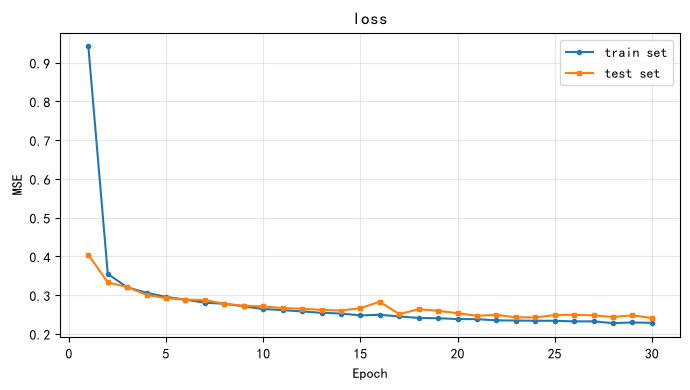

In [11]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_mse"], "o-", markersize=3, label="train set")
plt.plot(epochs_range, history["test_mse"],  "s-", markersize=3, label="test set")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 回归指标：RMSE / MAE / R²

常用回归指标：
- **RMSE**（均方根误差）：$\sqrt{\text{MSE}}$
- **MAE**（平均绝对误差）：$\frac{1}{N}\sum|\hat{y}-y|$
- **R²**：$1 - \frac{\sum(\hat{y}-y)^2}{\sum(\bar{y}-y)^2}$

In [12]:
# 收集测试集上的全部预测
model.eval()
preds_all, targets_all = [], []
with torch.no_grad():
    for features, targets in test_loader:
        preds_all.append(model(features.to(device)).cpu())
        targets_all.append(targets)
preds_all   = torch.cat(preds_all).squeeze().numpy()
targets_all = torch.cat(targets_all).squeeze().numpy()

# 计算指标
mse  = np.mean((preds_all - targets_all) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(preds_all - targets_all))
ss_res = np.sum((targets_all - preds_all) ** 2)               # 残差平方和
ss_tot = np.sum((targets_all - targets_all.mean()) ** 2)      # 总平方和
r2 = 1 - ss_res / ss_tot

print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")

RMSE = 0.4908
MAE  = 0.3343
R²   = 0.7393


### 5.3 可视化


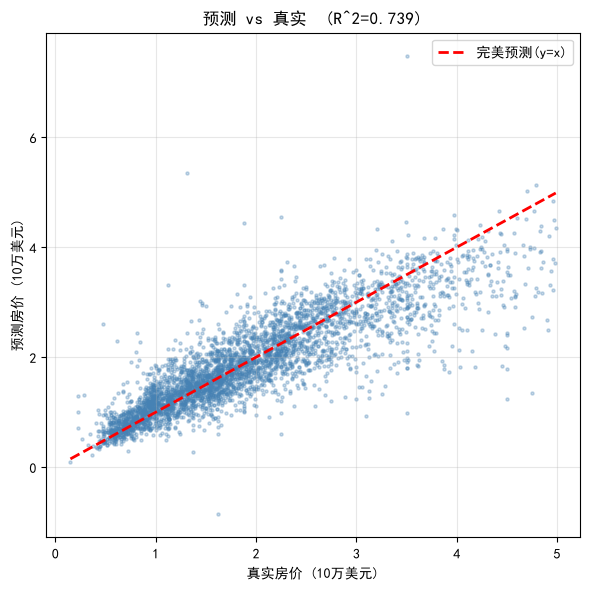

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(targets_all, preds_all, s=5, alpha=0.3, color="steelblue")
lims = [targets_all.min(), targets_all.max()]
plt.plot(lims, lims, "r--", lw=2, label="完美预测(y=x)")
plt.xlabel("真实房价 (10万美元)"); plt.ylabel("预测房价 (10万美元)")
plt.title(f"预测 vs 真实  (R^2={r2:.3f})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 小结与思考题

**回归 vs 分类，核心对照：**

| | 分类篇(CNN 手写数字) | 回归篇(MLP 房价) |
|---|---|---|
| 目标 | 离散类别 0~9 | 连续房价 |
| 模型 | 卷积网络 | 全连接网络(MLP) |
| 输出层 | 10 个 logits | **1 个值，无激活** |
| 损失 | 交叉熵 | **MSE 均方误差** |
| 评估 | 准确率、混淆矩阵 | **RMSE、MAE、R²、散点图** |
| **训练五步** | **完全相同** | **完全相同** |

**动手思考（可自行修改代码验证）：**
1. 把第 2 步的**特征标准化整段删掉**，直接用原始数据训练，MSE 会怎样？为什么？
2. 故意**用全体数据（而非仅训练集）计算 mu/sigma**，R² 会不会虚高？这说明了什么？
3. 给 MLP **加深/加宽**（多加几层或把 64 改成 128），R² 有提升吗？会过拟合吗？
4. 把输出层**错误地接上 `nn.ReLU()`**，预测会出什么问题？（提示：ReLU 把负数截成 0，但房价……）
5. 散点图里，房价在哪个区间预测得最差？结合 5.1 的数据分布想想原因（提示：数据集房价上限被截断在 5.0）。
